In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from qiskit_machine_learning.algorithms import QSVC

data = load_breast_cancer()
X, y = data.data, data.target

In [3]:
def simple_circuit(n_qubits):
    x = ParameterVector("x", n_qubits)
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.ry(x[i], i)          
    return qc

In [4]:
def run_once(n_qubits, seed):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    scaler = StandardScaler().fit(X_train)
    pca = PCA(n_components=n_qubits).fit(scaler.transform(X_train))
    to_angle = MinMaxScaler(feature_range=(0, np.pi)).fit(pca.transform(scaler.transform(X_train)))
    prepare = lambda A: to_angle.transform(pca.transform(scaler.transform(A)))
    X_train_q, X_test_q = prepare(X_train), prepare(X_test)

    models = {
        "Classical SVM": SVC(kernel="rbf"),
        "Quantum SVM (simple)": QSVC(quantum_kernel=FidelityStatevectorKernel(feature_map=simple_circuit(n_qubits))),
        "Quantum SVM (entangled)": QSVC(quantum_kernel=FidelityStatevectorKernel(feature_map=zz_feature_map(n_qubits, reps=2))),
    }
    rows = []
    for name, model in models.items():
        model.fit(X_train_q, y_train)
        acc = accuracy_score(y_test, model.predict(X_test_q))
        rows.append({"qubits": n_qubits, "split": seed, "model": name, "accuracy": acc})
    return rows

In [5]:
rows = []
for n_qubits in [2, 4, 6, 8]:
    for seed in range(5):
        rows += run_once(n_qubits, seed)
    print("Done:", n_qubits, "qubits")

results = pd.DataFrame(rows)
summary = results.groupby(["qubits", "model"])["accuracy"].agg(["mean", "std"]).round(3)
print(summary)

Done: 2 qubits
Done: 4 qubits
Done: 6 qubits
Done: 8 qubits
                                 mean    std
qubits model                                
2      Classical SVM            0.942  0.016
       Quantum SVM (entangled)  0.889  0.031
       Quantum SVM (simple)     0.942  0.024
4      Classical SVM            0.953  0.022
       Quantum SVM (entangled)  0.788  0.031
       Quantum SVM (simple)     0.961  0.015
6      Classical SVM            0.960  0.013
       Quantum SVM (entangled)  0.760  0.053
       Quantum SVM (simple)     0.967  0.007
8      Classical SVM            0.961  0.010
       Quantum SVM (entangled)  0.649  0.014
       Quantum SVM (simple)     0.965  0.009


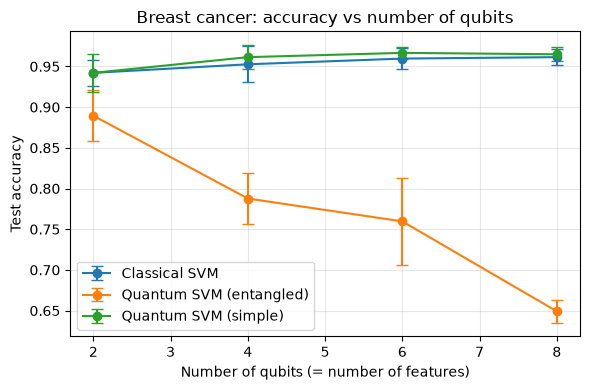

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, group in results.groupby("model"):
    stats = group.groupby("qubits")["accuracy"].agg(["mean", "std"])
    ax.errorbar(stats.index, stats["mean"], yerr=stats["std"], marker="o", capsize=4, label=name)

ax.set_xlabel("Number of qubits (= number of features)")
ax.set_ylabel("Test accuracy")
ax.set_title("Breast cancer: accuracy vs number of qubits")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

os.makedirs("../results", exist_ok=True)
fig.savefig("../results/exp1_accuracy_vs_qubits.png", dpi=150)
results.to_csv("../results/exp1_accuracy_vs_qubits.csv", index=False)
plt.show()